In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Constants
PARAM_COUNT = 11_191_262
MB_TO_BITS = 1024**2 * 8
reports_dir = Path("reports")

# Plot styling constants
MARKERS = ['o', 's', '^', 'D', 'v', 'X', 'P', '*', 'h', '+']
LINE_STYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
COLORS = {
    'acc': ['blue', 'navy', 'royalblue', 'steelblue', 'dodgerblue', 'cornflowerblue'],
    'bitrate': ['red', 'darkred', 'crimson', 'firebrick', 'indianred', 'lightcoral'],
    'auc': ['green', 'darkgreen', 'forestgreen', 'seagreen', 'mediumseagreen', 'springgreen'],
    'mape': ['orange', 'darkorange', 'orangered', 'coral', 'tomato', 'lightsalmon']
}


In [86]:
def preprocess_tensor_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Convert tensor format columns to numeric values."""
    df_processed = df.copy()
    tensor_columns = ['train_auc', 'val_auc', 'train_acc', 'val_acc']

    for col in tensor_columns:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].astype(str).apply(
                lambda x: float(re.findall(r'[\d\.]+', x)[0]) if 'tensor' in x else float(x)
            )
    return df_processed

def calculate_bit_rate(mbytes_received: float) -> float:
    """Calculate bit rate from mbytes received."""
    return (mbytes_received * MB_TO_BITS) / PARAM_COUNT

def load_data() -> Tuple[Dict[str, pd.DataFrame], Dict[str, pd.DataFrame], Dict[str, pd.DataFrame]]:
    """Load and process all experiment data."""
    auc_data, broadcast_data, wz_training_data = {}, {}, {}

    if not reports_dir.exists():
        print(f"Reports directory {reports_dir} not found!")
        return auc_data, broadcast_data, wz_training_data

    for exp_folder in reports_dir.iterdir():
        if not exp_folder.is_dir():
            continue

        exp_name = exp_folder.name

        # Load AUC data
        global_metrics_file = exp_folder / "_global_metrics_before_round_start.csv"
        if global_metrics_file.exists():
            df = pd.read_csv(global_metrics_file)
            auc_data[exp_name] = preprocess_tensor_columns(df)

        # Load broadcast data
        wz_file = exp_folder / "_broadcast_protocol_stats" / "wz.csv"
        if wz_file.exists():
            df = pd.read_csv(wz_file)
            numeric_cols = ['mbytes_recived', 'mse', 'mape%', 'mae']
            for col in numeric_cols:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

            df_averaged = df.groupby('round_id')[numeric_cols].mean().reset_index()
            if 'mbytes_recived' in df_averaged.columns:
                df_averaged['bit_rate'] = df_averaged['mbytes_recived'].apply(calculate_bit_rate)
            broadcast_data[exp_name] = df_averaged

        # Load WZ training data
        wz_logs_folder = exp_folder / "wz_training_logs"
        if wz_logs_folder.exists():
            round_data = []
            for round_folder in wz_logs_folder.iterdir():
                if round_folder.is_dir() and round_folder.name.startswith("round_"):
                    try:
                        parts = round_folder.name.split("_")
                        round_id, agent_id = int(parts[1]), int(parts[3])

                        metrics_file = round_folder / "metrics.csv"
                        if metrics_file.exists():
                            df = pd.read_csv(metrics_file)
                            val_data = df.dropna(subset=['val_mape%', 'val_rate_bits'])
                            if len(val_data) > 0:
                                last_val = val_data.iloc[-1]
                                round_data.append({
                                    'round_id': round_id, 'agent_id': agent_id,
                                    'val_mape%': last_val['val_mape%'],
                                    'val_rate_bits': last_val['val_rate_bits']
                                })
                    except (ValueError, IndexError, KeyError):
                        continue

            if round_data:
                df_rounds = pd.DataFrame(round_data)
                df_averaged = df_rounds.groupby('round_id')[['val_mape%', 'val_rate_bits']].mean().reset_index()
                df_averaged['theoretical_bit_rate'] = df_averaged['val_rate_bits']
                wz_training_data[exp_name] = df_averaged

    print(f"Loaded data: {len(auc_data)} AUC, {len(broadcast_data)} broadcast, {len(wz_training_data)} WZ training")
    return auc_data, broadcast_data, wz_training_data


In [87]:
def plot_twin_axes(data_dict: Dict[str, pd.DataFrame],
                   left_col: str, right_col: str,
                   left_label: str, right_label: str,
                   left_color: str, right_color: str,
                   title: str, right_data_dict: Optional[Dict] = None,
                   y_lim_right: Optional[Tuple] = None):
    """Generic function for twin Y-axes plots."""
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()
    
    right_dict = right_data_dict or data_dict

    for i, (exp_name, df) in enumerate(data_dict.items()):
        marker = MARKERS[i % len(MARKERS)]
        line_style = LINE_STYLES[i % len(LINE_STYLES)]
        left_col_color = COLORS[left_color][i % len(COLORS[left_color])]
        right_col_color = COLORS[right_color][i % len(COLORS[right_color])]

        # Left axis plot
        if left_col in df.columns:
            ax1.plot(df['round_id'], df[left_col],
                    color=left_col_color, marker=marker, markersize=8, linewidth=2,
                    linestyle=line_style, label=f'{exp_name} - {left_label}',
                    alpha=0.8, markeredgewidth=0)

        # Right axis plot
        if exp_name in right_dict and right_col in right_dict[exp_name].columns:
            right_df = right_dict[exp_name]
            ax2.plot(right_df['round_id'], right_df[right_col],
                    color=right_col_color, marker=marker, markersize=8, linewidth=2,
                    linestyle=line_style, label=f'{exp_name} - {right_label}',
                    alpha=0.8, markeredgewidth=0)

    # Formatting
    ax1.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel(left_label, fontsize=12, fontweight='bold', color=left_col_color)
    ax2.set_ylabel(right_label, fontsize=12, fontweight='bold', color=right_col_color)
    ax1.tick_params(axis='y', labelcolor=left_col_color)
    ax2.tick_params(axis='y', labelcolor=right_col_color)

    if y_lim_right:
        ax2.set_ylim(y_lim_right)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_scatter_subplots(data_dict: Dict[str, pd.DataFrame],
                         x_col: str, y_col: str,
                         x_label: str, y_label: str,
                         title_suffix: str,
                         x_lim: Tuple = (0.4, 4.1),
                         y_lim: Tuple = (5, 50),
                         log_y: bool = True):
    """Generic function for scatter subplot grids."""
    n_experiments = len(data_dict)
    if n_experiments == 0:
        print(f"No data available for {title_suffix} plots.")
        return
    
    n_cols = min(2, n_experiments)
    n_rows = (n_experiments + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_experiments == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes_flat = axes.flatten() if n_experiments > 1 else axes
    
    for i, (exp_name, df) in enumerate(data_dict.items()):
        ax = axes_flat[i]
        marker = MARKERS[i % len(MARKERS)]

        if x_col in df.columns and y_col in df.columns:
            scatter = ax.scatter(df[x_col], df[y_col],
                               c=df['round_id'], cmap='viridis',
                               s=80, alpha=0.8, linewidths=0, marker=marker)

            plt.colorbar(scatter, ax=ax).set_label('Communication Round', fontsize=10)

            ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
            ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
            ax.set_title(f'{exp_name.title()} Protocol\n{title_suffix}', fontsize=12, fontweight='bold')
            ax.set_xlim(x_lim)
            ax.set_ylim(y_lim)
            if log_y:
                ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(n_experiments, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


In [88]:
# Load all data
auc_data, broadcast_data, wz_training_data = load_data()

# Display summary statistics
print("\n=== SUMMARY STATISTICS ===")
for exp_name in set(list(auc_data.keys()) + list(broadcast_data.keys())):
    print(f"\n{exp_name.upper()} EXPERIMENT:")

    if exp_name in auc_data:
        auc_df = auc_data[exp_name]
        print(f"  AUC Data: {len(auc_df)} rounds")
        for col, label in [('val_auc', 'Final Val AUC'), ('val_acc', 'Final Val Acc')]:
            if col in auc_df.columns:
                print(f"  {label}: {auc_df[col].iloc[-1]:.4f}")

    if exp_name in broadcast_data:
        bc_df = broadcast_data[exp_name]
        print(f"  Broadcast Data: {len(bc_df)} rounds")
        for col, label in [('bit_rate', 'Avg Bit Rate'), ('mape%', 'Avg MAPE%')]:
            if col in bc_df.columns:
                print(f"  {label}: {bc_df[col].mean():.4f}")


Loaded data: 3 AUC, 3 broadcast, 3 WZ training

=== SUMMARY STATISTICS ===

ALL_OUT_NO_GLOBAL_QUANT EXPERIMENT:
  AUC Data: 51 rounds
  Final Val AUC: 0.9570
  Broadcast Data: 50 rounds
  Avg Bit Rate: 2.0958
  Avg MAPE%: 33.1582

HYBRID_NO_GLOBAL_QUANT EXPERIMENT:
  AUC Data: 51 rounds
  Final Val AUC: 0.9573
  Broadcast Data: 50 rounds
  Avg Bit Rate: 2.2149
  Avg MAPE%: 25.8445

WORKER-SIDE_NO_GLOBAL_QUANT EXPERIMENT:
  AUC Data: 51 rounds
  Final Val AUC: 0.9602
  Broadcast Data: 50 rounds
  Avg Bit Rate: 2.1250
  Avg MAPE%: 22.5918



Generating plots...
1. Creating Validation Accuracy vs Bit Rate plot...


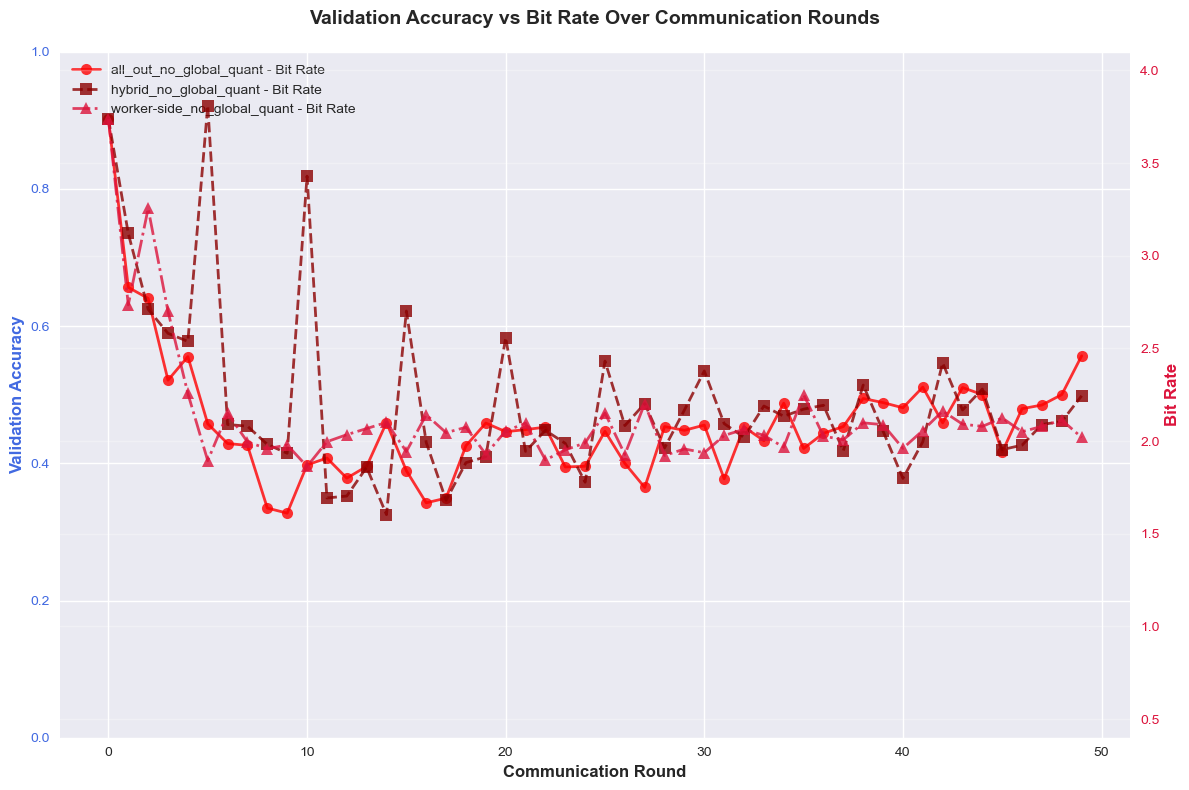

2. Creating Validation AUC vs MAPE% plot...


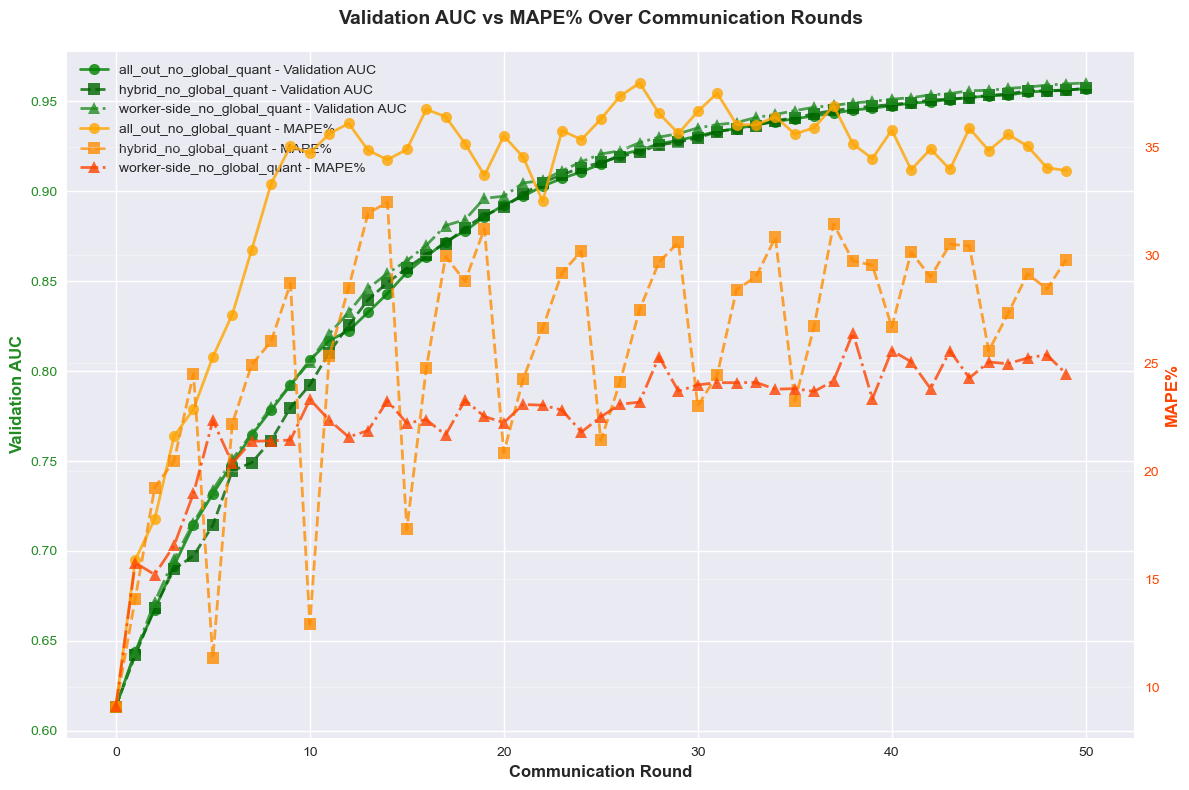

3. Creating Rate-Distortion scatter plots...


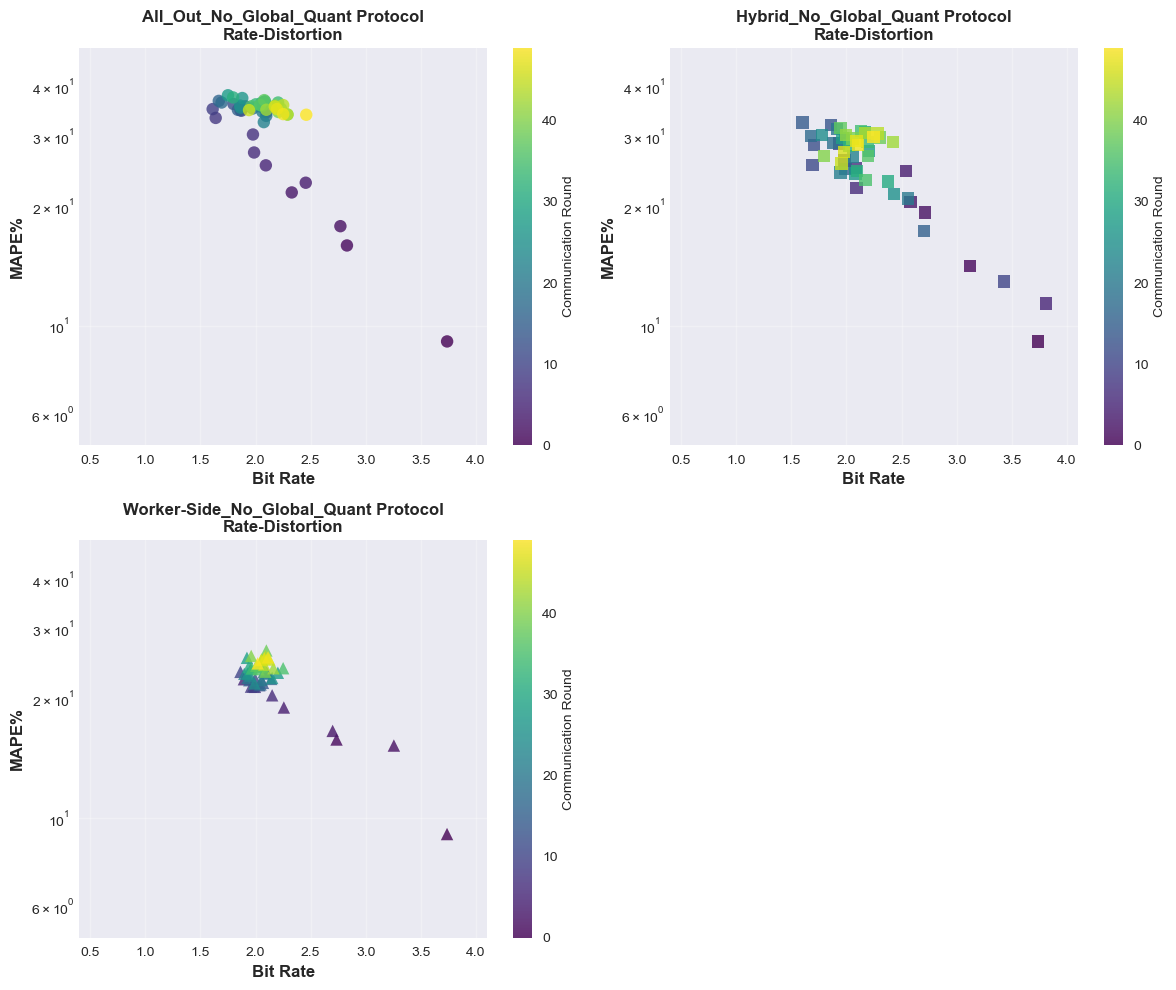

In [89]:
# Generate all plots
print("\nGenerating plots...")

print("1. Creating Validation Accuracy vs Bit Rate plot...")
plot_twin_axes(auc_data, 'val_acc', 'bit_rate',
               'Validation Accuracy', 'Bit Rate', 'acc', 'bitrate',
               'Validation Accuracy vs Bit Rate Over Communication Rounds',
               broadcast_data, (0.4, 4.1))

print("2. Creating Validation AUC vs MAPE% plot...")
plot_twin_axes(auc_data, 'val_auc', 'mape%',
               'Validation AUC', 'MAPE%', 'auc', 'mape',
               'Validation AUC vs MAPE% Over Communication Rounds',
               broadcast_data)

print("3. Creating Rate-Distortion scatter plots...")
plot_scatter_subplots(broadcast_data, 'bit_rate', 'mape%',
                     'Bit Rate', 'MAPE%', 'Rate-Distortion')


4. Creating per-experiment analysis plots...


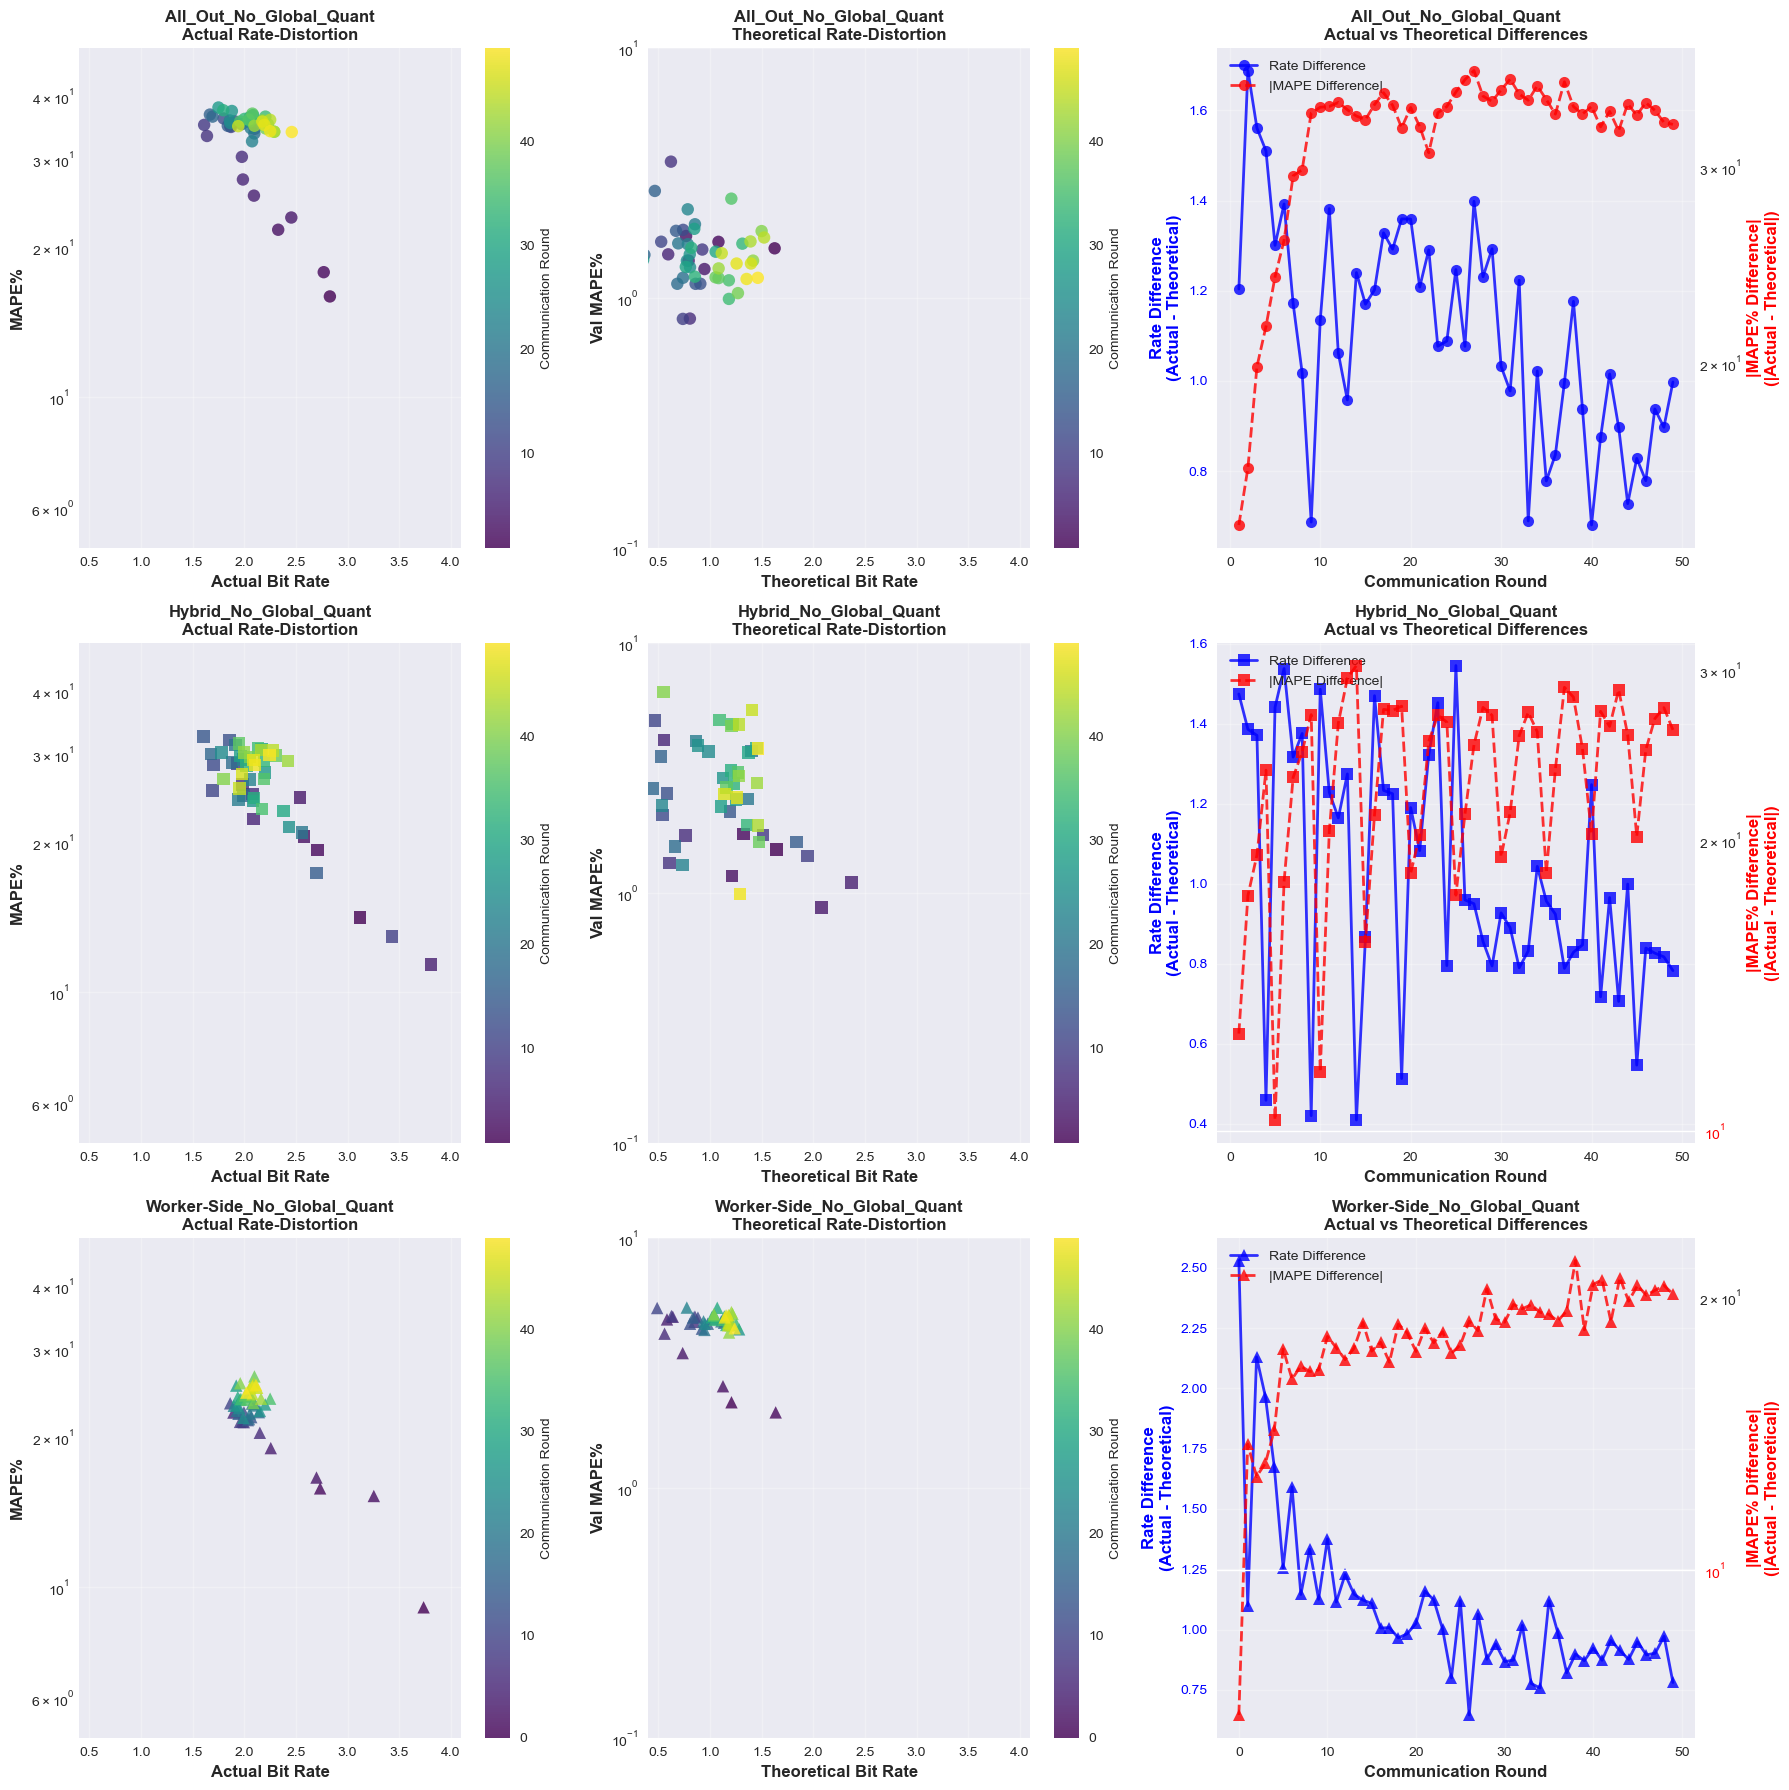


All plots generated successfully!


In [90]:
def plot_per_experiment_analysis():
    """Create per-experiment analysis plots with simplified logic."""
    if not wz_training_data:
        print("No WZ training data available for per-experiment analysis.")
        return

    common_experiments = set(broadcast_data.keys()) & set(wz_training_data.keys())
    if not common_experiments:
        print("No experiments found with both broadcast and WZ training data.")
        return
    
    n_experiments = len(common_experiments)
    fig = plt.figure(figsize=(18, 6 * n_experiments))
    
    for exp_idx, exp_name in enumerate(sorted(common_experiments)):
        actual_data = broadcast_data[exp_name]
        theoretical_data = wz_training_data[exp_name]

        # Merge data on common rounds (automatically excludes round 0 if no theoretical data)
        merged_data = pd.merge(
            actual_data[['round_id', 'bit_rate', 'mape%']],
            theoretical_data[['round_id', 'theoretical_bit_rate', 'val_mape%']],
            on='round_id', how='inner'
        )

        if len(merged_data) == 0:
            print(f"No common rounds found for {exp_name}")
            continue

        marker = MARKERS[exp_idx % len(MARKERS)]

        # Plot configurations: (subplot_idx, x_col, y_col, x_label, y_label, title, y_lim)
        plots = [
            (1, 'bit_rate', 'mape%', 'Actual Bit Rate', 'MAPE%', 'Actual Rate-Distortion', (5, 50)),
            (2, 'theoretical_bit_rate', 'val_mape%', 'Theoretical Bit Rate', 'Val MAPE%', 'Theoretical Rate-Distortion', (0.1, 10))
        ]

        for subplot_idx, x_col, y_col, x_label, y_label, title, y_lim in plots:
            ax = plt.subplot(n_experiments, 3, exp_idx * 3 + subplot_idx)

            scatter = ax.scatter(merged_data[x_col], merged_data[y_col],
                               c=merged_data['round_id'], cmap='viridis',
                               s=80, alpha=0.8, linewidths=0, marker=marker)

            ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
            ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
            ax.set_title(f'{exp_name.title()}\n{title}', fontsize=12, fontweight='bold')
            ax.set_xlim(0.4, 4.1)
            ax.set_yscale('log')
            ax.set_ylim(y_lim)
            ax.grid(True, alpha=0.3)

            plt.colorbar(scatter, ax=ax).set_label('Communication Round', fontsize=10)

        # Plot 3: Differences
        ax3 = plt.subplot(n_experiments, 3, exp_idx * 3 + 3)
        ax3_twin = ax3.twinx()

        rate_diff = merged_data['bit_rate'] - merged_data['theoretical_bit_rate']
        mape_diff = np.abs(merged_data['mape%'] - merged_data['val_mape%'])

        ax3.plot(merged_data['round_id'], rate_diff,
                color='blue', marker=marker, markersize=8, linewidth=2,
                label='Rate Difference', alpha=0.8, markeredgewidth=0)

        ax3_twin.plot(merged_data['round_id'], mape_diff,
                     color='red', marker=marker, markersize=8, linewidth=2,
                     linestyle='--', label='|MAPE Difference|', alpha=0.8, markeredgewidth=0)

        ax3.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Rate Difference\n(Actual - Theoretical)', fontsize=12, fontweight='bold', color='blue')
        ax3_twin.set_ylabel('|MAPE% Difference|\n(|Actual - Theoretical|)', fontsize=12, fontweight='bold', color='red')
        ax3.set_title(f'{exp_name.title()}\nActual vs Theoretical Differences', fontsize=12, fontweight='bold')

        ax3.tick_params(axis='y', labelcolor='blue')
        ax3_twin.tick_params(axis='y', labelcolor='red')
        ax3_twin.set_yscale('log')
        ax3.grid(True, alpha=0.3)

        # Legend
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3_twin.get_legend_handles_labels()
        ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Generate per-experiment analysis plots
print("4. Creating per-experiment analysis plots...")
plot_per_experiment_analysis()

print("\nAll plots generated successfully!")


In [91]:
def compare_final_metrics():
    """Compare final metrics across all experiments."""
    all_experiments = set(list(auc_data.keys()) + list(broadcast_data.keys()))
    comparison_data = []

    for exp_name in all_experiments:
        row = {'experiment': exp_name}

        # AUC/accuracy metrics
        if exp_name in auc_data and len(auc_data[exp_name]) > 0:
            final_row = auc_data[exp_name].iloc[-1]
            for col, key in [('val_auc', 'final_val_auc'), ('val_acc', 'final_val_acc'), ('train_loss', 'final_train_loss')]:
                row[key] = final_row.get(col, np.nan)

        # Communication metrics
        if exp_name in broadcast_data and len(broadcast_data[exp_name]) > 0:
            bc_df = broadcast_data[exp_name]
            for col, key_avg, key_final in [('bit_rate', 'avg_bit_rate', None), ('mape%', 'avg_mape', 'final_mape')]:
                if col in bc_df.columns:
                    row[key_avg] = bc_df[col].mean()
                    if key_final:
                        row[key_final] = bc_df[col].iloc[-1]

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)
    print("\n=== FINAL METRICS COMPARISON ===")
    print(comparison_df.to_string(index=False, float_format='%.4f'))
    return comparison_df

# Run comparison
comparison_df = compare_final_metrics()

print("\n=== SCRIPT COMPLETION ===")
print("✓ All data preprocessing and plotting functions completed")
print("✓ Code simplified and made more reusable")
print("✓ Ready for additional experiments - just add new folders to reports/")



=== FINAL METRICS COMPARISON ===
                 experiment  final_val_auc  final_val_acc  final_train_loss  avg_bit_rate  avg_mape  final_mape
    all_out_no_global_quant         0.9570            NaN            0.7266        2.0958   33.1582     33.9312
     hybrid_no_global_quant         0.9573            NaN            0.7142        2.2149   25.8445     29.8125
worker-side_no_global_quant         0.9602            NaN            0.6779        2.1250   22.5918     24.5094

=== SCRIPT COMPLETION ===
✓ All data preprocessing and plotting functions completed
✓ Code simplified and made more reusable
✓ Ready for additional experiments - just add new folders to reports/
